In [1]:
import numpy as np
import xarray as xr

def cloud_base_index(ref, lev_dim='lev'):
    """
    Index of the cloud-base level per (time, lat, lon): the lowest-altitude
    level with valid data, scanning from the surface upward.
    Assumes lev is ascending pressure (index 0 = highest altitude,
    last index = nearest surface), as in this dataset (691→992 hPa).
    Returns (idx, has_cloud): idx is the chosen lev index, has_cloud flags
    columns with at least one valid level.
    """
    valid = np.isfinite(ref.values)                  # (time, lev, lat, lon)
    nlev = valid.shape[1]
    # surface is the LAST lev index → reverse so argmax finds surface-most first
    rev_first = np.argmax(valid[:, ::-1, :, :], axis=1)
    idx = (nlev - 1) - rev_first
    has_cloud = valid.any(axis=1)
    return idx, has_cloud


def at_cloud_base(var, idx, has_cloud):
    """
    Sample `var` (time, lev, lat, lon) at the given cloud-base level index,
    returning (time, lat, lon) with NaN where no cloud exists.
    """
    a = var.values
    ti, la, lo = np.meshgrid(
        np.arange(a.shape[0]), np.arange(a.shape[2]), np.arange(a.shape[3]),
        indexing='ij'
    )
    out = a[ti, idx, la, lo].astype('float32')
    out = np.where(has_cloud, out, np.nan)
    return xr.DataArray(
        out, dims=('time', 'lat', 'lon'),
        coords={'time': var['time'], 'lat': var['lat'], 'lon': var['lon']},
        name=f'{var.name}_cloudbase'
    )

In [2]:
Updraft = xr.open_dataset("/share/pech2273/smax_ratios/WSUB.nc")
NorPath = "/share/pech2273/combined.nc"
CDNC = xr.open_dataset(NorPath, chunks={})
smax = xr.open_dataset("/share/pech2273/smax_ratios/smax_ratios.nc")
CDNC = CDNC.CDNC

In [3]:
idx, has_cloud = cloud_base_index(CDNC)

In [7]:
Updraft_CB = at_cloud_base(Updraft.WSUB, idx, has_cloud)

In [8]:
Updraft_CB

<xarray.DataArray 'WSUB_cloudbase' (time: 11689, lat: 96, lon: 144)> Size: 646MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan, 0.26496857, ...,        nan,
                nan,        nan],
...
        [0.2       , 0.2       , 0.2       , ..., 0.2       ,
         0.31969416, 0.29418457],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan, 0.2       ,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(11689, 96, 144), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 94kB 2011-01-01 ... 2015-01-01
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

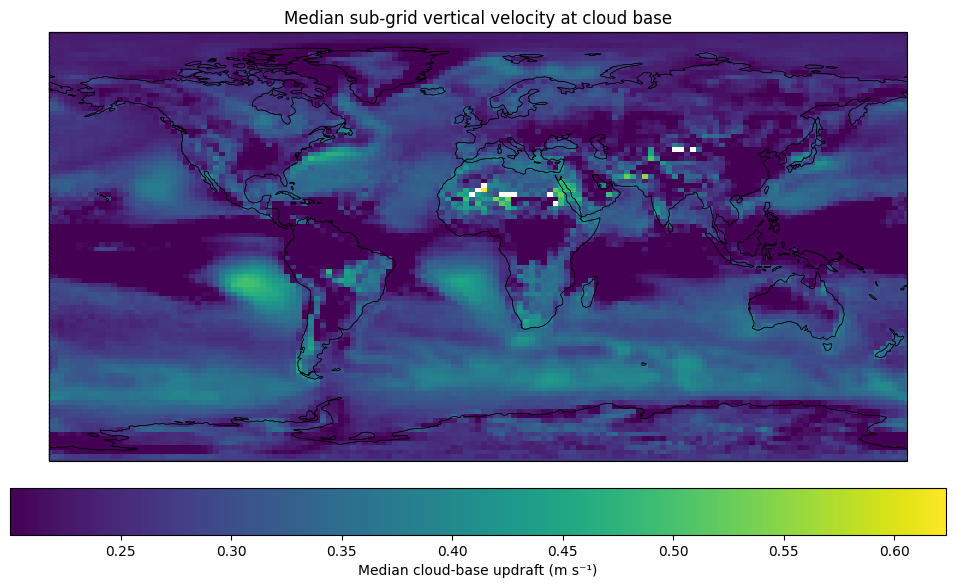

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Median updraft at cloud base, per grid cell, over time
updraft_median = Updraft_CB.median(dim='time', skipna=True)   # (lat, lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    updraft_median['lon'].values,
    updraft_median['lat'].values,
    updraft_median.values,
    cmap='viridis',
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=0.3, zorder=2)
ax.set_global()

cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cb.set_label('Median cloud-base updraft (m s⁻¹)')

ax.set_title('Median sub-grid vertical velocity at cloud base')
plt.tight_layout()
plt.show()

In [11]:
CDNC_CB = at_cloud_base(CDNC, idx, has_cloud)

In [12]:
smax_incld_CB = at_cloud_base(smax.incld_ratio, idx, has_cloud)
smax_cldv_CB = at_cloud_base(smax.cldv_ratio, idx, has_cloud)
smax_CB = np.maximum(smax_incld_CB, smax_cldv_CB)


In [13]:
smax_CB

<xarray.DataArray 'incld_ratio_cloudbase' (time: 11689, lat: 96, lon: 144)> Size: 646MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan, 0.03052252, ...,        nan,
                nan,        nan],
...
        [0.00379678, 0.00389541,        nan, ..., 0.00568857,
         0.00635886, 0.0053823 ],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan, 0.00751533,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(11689, 96, 144), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 94kB 2011-01-01 ... 2015-01-01
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

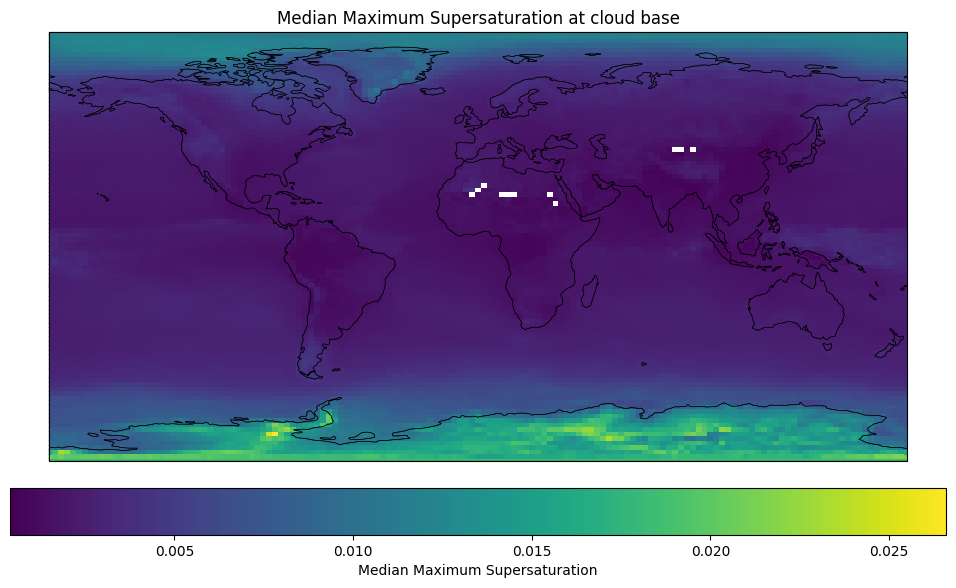

In [15]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Median updraft at cloud base, per grid cell, over time
smax_median = smax_CB.median(dim='time', skipna=True)   # (lat, lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    smax_median['lon'].values,
    smax_median['lat'].values,
    smax_median.values,
    cmap='viridis',
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=0.3, zorder=2)
ax.set_global()

cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cb.set_label('Median Maximum Supersaturation')

ax.set_title('Median Maximum Supersaturation at cloud base')
plt.tight_layout()
plt.show()

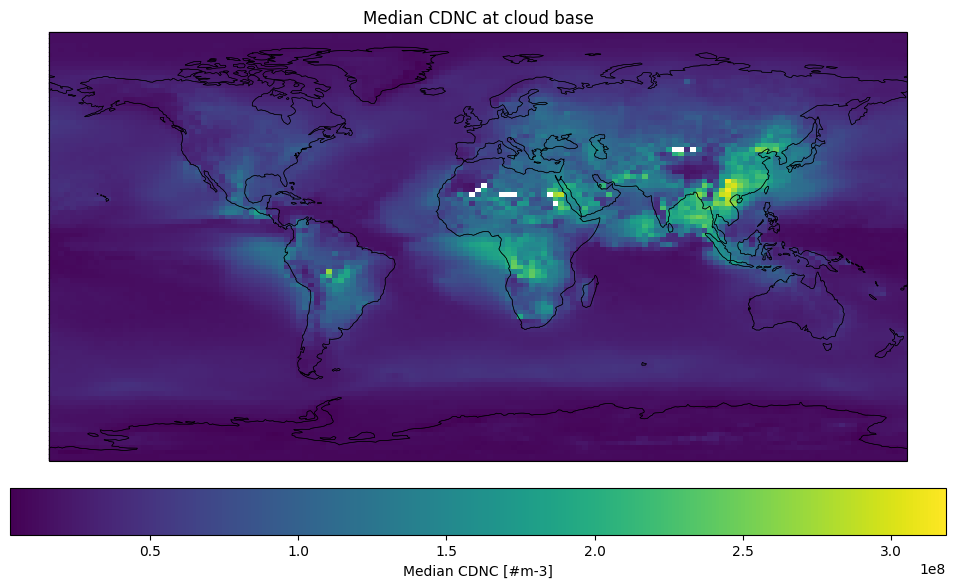

In [16]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Median updraft at cloud base, per grid cell, over time
CDNC_median = CDNC_CB.median(dim='time', skipna=True)   # (lat, lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    CDNC_median['lon'].values,
    CDNC_median['lat'].values,
    CDNC_median.values,
    cmap='viridis',
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=0.3, zorder=2)
ax.set_global()

cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cb.set_label('Median CDNC [#m-3]')

ax.set_title('Median CDNC at cloud base')
plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd

# Flatten all three to 1D, keep only points valid in all three
s = smax_CB.values.ravel()
c = CDNC_CB.values.ravel()
u = Updraft_CB.values.ravel()

m = np.isfinite(s) & np.isfinite(c) & np.isfinite(u)
df = pd.DataFrame({'Smax': s[m], 'CDNC': c[m], 'Updraft': u[m]})

# Often these span orders of magnitude → log helps linearity (drop non-positive first)
print("Pearson (raw):\n", df.corr())
logdf = np.log(df.where(df > 0)).dropna()
print("\nPearson (log):\n", logdf.corr())
print("\nSpearman (rank, robust to nonlinearity):\n", df.corr(method='spearman'))


Pearson (raw):
              Smax      CDNC   Updraft
Smax     1.000000 -0.258303  0.116443
CDNC    -0.258303  1.000000  0.195017
Updraft  0.116443  0.195017  1.000000

Pearson (log):
              Smax      CDNC   Updraft
Smax     1.000000 -0.628201  0.232109
CDNC    -0.628201  1.000000  0.238738
Updraft  0.232109  0.238738  1.000000

Spearman (rank, robust to nonlinearity):
              Smax      CDNC   Updraft
Smax     1.000000 -0.565034  0.248282
CDNC    -0.565034  1.000000  0.268471
Updraft  0.248282  0.268471  1.000000


In [22]:
import xarray as xr

def corr_map(a, b, min_n=50):
    """Pearson correlation over time per (lat,lon), NaN where too few points."""
    n = np.isfinite(a) & np.isfinite(b)
    cnt = n.sum(dim='time')
    am = a.where(n); bm = b.where(n)
    am = am - am.mean('time'); bm = bm - bm.mean('time')
    cov = (am * bm).mean('time')
    r = cov / (am.std('time') * bm.std('time'))
    return r.where(cnt >= min_n)

r_smax_cdnc    = corr_map(smax_CB, CDNC_CB)
r_smax_updraft = corr_map(smax_CB, Updraft_CB)
r_cdnc_updraft = corr_map(CDNC_CB, Updraft_CB)

In [65]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pairs = [(r_smax_cdnc, 'Smax vs N70')]

fig, axes = plt.figure(1, 1, figsize=(10, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, (r, title) in zip(axes, pairs):
    im = ax.pcolormesh(r['lon'], r['lat'], r.values,
                       cmap='RdBu_r', vmin=-1, vmax=1,
                       transform=ccrs.PlateCarree(), shading='auto')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_global(); ax.set_title(title)
    plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, label='Pearson r')
plt.tight_layout(); plt.show()

TypeError: figure() got multiple values for argument 'figsize'

In [21]:
import numpy as np

# Use the log-transformed, all-positive sample
ls, lc, lu = logdf['Smax'].values, logdf['CDNC'].values, logdf['Updraft'].values
R = np.corrcoef(np.vstack([ls, lc, lu]))   # 3x3 Pearson matrix

def partial(R, i, j, k):
    return (R[i,j] - R[i,k]*R[j,k]) / np.sqrt((1-R[i,k]**2)*(1-R[j,k]**2))

print("Smax–CDNC | Updraft :", partial(R, 0, 1, 2))
print("Smax–Updraft | CDNC :", partial(R, 0, 2, 1))
print("CDNC–Updraft | Smax :", partial(R, 1, 2, 0))

Smax–CDNC | Updraft : -0.7237349019202551
Smax–Updraft | CDNC : 0.5057006692493072
CDNC–Updraft | Smax : 0.5081224962617554


In [24]:
from scipy.stats import rankdata
import numpy as np

# Rank-transform each, then same partial-correlation formula
Rr = np.corrcoef(np.vstack([rankdata(ls), rankdata(lc), rankdata(lu)]))
print("Spearman partials:")
print("  Smax–CDNC | Updraft :", partial(Rr, 0, 1, 2))
print("  Smax–Updraft | CDNC :", partial(Rr, 0, 2, 1))
print("  CDNC–Updraft | Smax :", partial(Rr, 1, 2, 0))

Spearman partials:
  Smax–CDNC | Updraft : -0.6769628398362907
  Smax–Updraft | CDNC : 0.5032572995247165
  CDNC–Updraft | Smax : 0.5114392110841273


In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Pull the three cloud-base fields as arrays (time, lat, lon)
S = smax_CB.values
C = CDNC_CB.values
U = Updraft_CB.values

ntime, nlat, nlon = S.shape
MIN_N = 50   # require this many joint valid timesteps per cell

def partial(R, i, j, k):
    denom = np.sqrt((1 - R[i,k]**2) * (1 - R[j,k]**2))
    if denom == 0:
        return np.nan
    return (R[i,j] - R[i,k]*R[j,k]) / denom

pr_smax_cdnc = np.full((nlat, nlon), np.nan, dtype=np.float32)

for a in range(nlat):
    for b in range(nlon):
        s, c, u = S[:, a, b], C[:, a, b], U[:, a, b]
        m = np.isfinite(s) & np.isfinite(c) & np.isfinite(u) & (s > 0) & (c > 0) & (u > 0)
        if m.sum() < MIN_N:
            continue
        ls, lc, lu = np.log(s[m]), np.log(c[m]), np.log(u[m])
        # need variance in all three to correlate
        if ls.std() == 0 or lc.std() == 0 or lu.std() == 0:
            continue
        R = np.corrcoef(np.vstack([ls, lc, lu]))
        pr_smax_cdnc[a, b] = partial(R, 0, 1, 2)

# Wrap into a DataArray on the shared coords
pr_map = xr.DataArray(
    pr_smax_cdnc, dims=('lat', 'lon'),
    coords={'lat': smax_CB['lat'], 'lon': smax_CB['lon']},
    name='partial_corr_Smax_CDNC_given_Updraft'
)

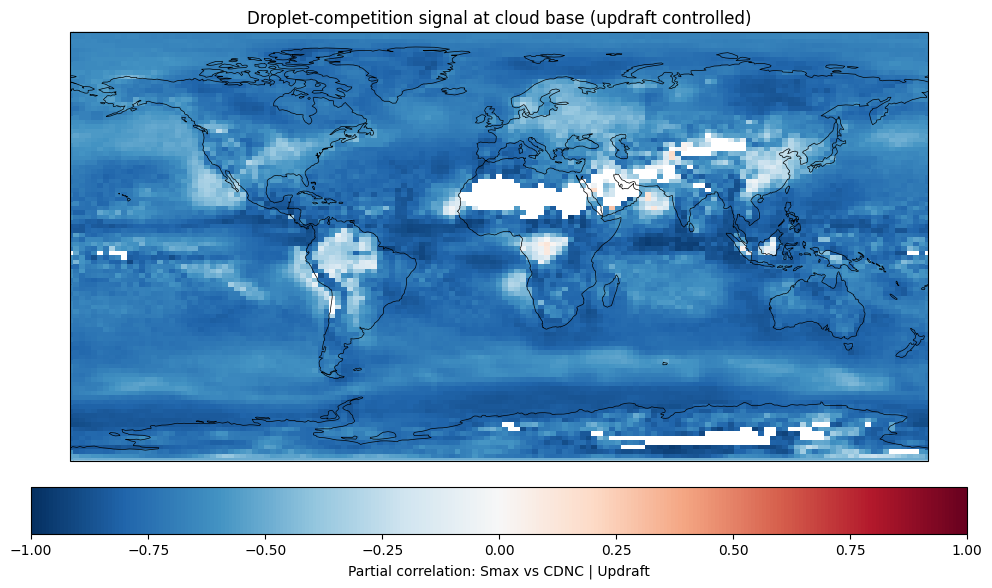

In [27]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    pr_map['lon'], pr_map['lat'], pr_map.values,
    cmap='RdBu_r', vmin=-1, vmax=1,
    transform=ccrs.PlateCarree(), shading='auto'
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()

cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cb.set_label('Partial correlation: Smax vs CDNC | Updraft')
ax.set_title('Droplet-competition signal at cloud base (updraft controlled)')
plt.tight_layout()
plt.show()

In [28]:
print('valid cells:', int(np.isfinite(pr_map).sum()), '/', pr_map.size)
print('area-weighted mean:', float(pr_map.weighted(np.cos(np.deg2rad(pr_map['lat']))).mean()))

valid cells: 13509 / 13824
area-weighted mean: -0.6940895961275286


In [29]:
N70 = xr.open_dataset("/share/pech2273/NorESM_CDNC_CCN/N70.nc")
N100 = xr.open_dataset("/share/pech2273/NorESM_CDNC_CCN/N100.nc")
N20 = xr.open_dataset("/share/pech2273/NorESM_CDNC_CCN/N20.nc")


In [30]:
from shapely.geometry import Point
from shapely.ops import unary_union
import cartopy.feature as cfeature
import numpy as np

land_geom = unary_union(list(cfeature.LAND.geometries()))

lon = pr_map['lon'].values
lat = pr_map['lat'].values
lon180 = np.where(lon > 180, lon - 360, lon)   # cartopy wants -180..180

is_land = np.zeros((len(lat), len(lon)), dtype=bool)
for i, la in enumerate(lat):
    for j, lo in enumerate(lon180):
        is_land[i, j] = land_geom.contains(Point(lo, la))
is_ocean = ~is_land

In [34]:
N70_CB = at_cloud_base(N70.N70, idx, has_cloud)

In [35]:
N20_CB = at_cloud_base(N20.N20, idx, has_cloud)
N100_CB = at_cloud_base(N100.N100, idx, has_cloud)

In [36]:
N70_CB

<xarray.DataArray 'N70_cloudbase' (time: 11689, lat: 96, lon: 144)> Size: 646MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,   514469.56, ...,         nan,
                 nan,         nan],
...
         27027860.  , 36480176.  ],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, 13474604.  ,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]],
      shape=(11689, 96, 144), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 94kB 2011-01-01 ... 2015-01-01
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [38]:
import numpy as np
import xarray as xr

N_BINS, MIN_PER_BIN, MIN_BINS = 20, 4, 20

def binned_slope(x, y):
    if x.size < N_BINS * MIN_PER_BIN:
        return np.nan
    order = np.argsort(x); x, y = x[order], y[order]
    mx, my = [], []
    for chunk in np.array_split(np.arange(x.size), N_BINS):
        if chunk.size >= MIN_PER_BIN:
            mx.append(np.median(x[chunk])); my.append(np.median(y[chunk]))
    if len(mx) < MIN_BINS:
        return np.nan
    return np.polyfit(mx, my, 1)[0]

def susceptibility_map(ccn_cb, cdnc_cb):
    """Log-log binned-median slope of CDNC against a CCN proxy, per grid cell."""
    X = np.log(ccn_cb.values)      # (time, lat, lon)
    Y = np.log(cdnc_cb.values)
    finite = np.isfinite(X) & np.isfinite(Y)
    nlat, nlon = X.shape[1], X.shape[2]
    slope = np.full((nlat, nlon), np.nan, dtype=np.float32)
    for i in range(nlat):
        for j in range(nlon):
            m = finite[:, i, j]
            if m.sum() >= N_BINS * MIN_PER_BIN:
                slope[i, j] = binned_slope(X[m, i, j], Y[m, i, j])
    return xr.DataArray(
        slope, dims=('lat', 'lon'),
        coords={'lat': cdnc_cb['lat'], 'lon': cdnc_cb['lon']},
        name='susceptibility'
    )

# Run for each CCN proxy at cloud base
suscept = {}
for name, ccn_cb in [('N20', N20_CB), ('N70', N70_CB), ('N100', N100_CB)]:
    print(f'computing susceptibility vs {name}...')
    suscept[name] = susceptibility_map(ccn_cb, CDNC_CB)
    s = suscept[name]
    w = np.cos(np.deg2rad(s['lat']))
    print(f'  valid: {int(np.isfinite(s).sum())}/{s.size}, '
          f'area-wt median region ~ {float(s.where(np.isfinite(s)).weighted(w).mean()):.3f}')

computing susceptibility vs N20...
  valid: 13258/13824, area-wt median region ~ 0.492
computing susceptibility vs N70...
  valid: 13258/13824, area-wt median region ~ 0.522
computing susceptibility vs N100...
  valid: 13258/13824, area-wt median region ~ 0.556


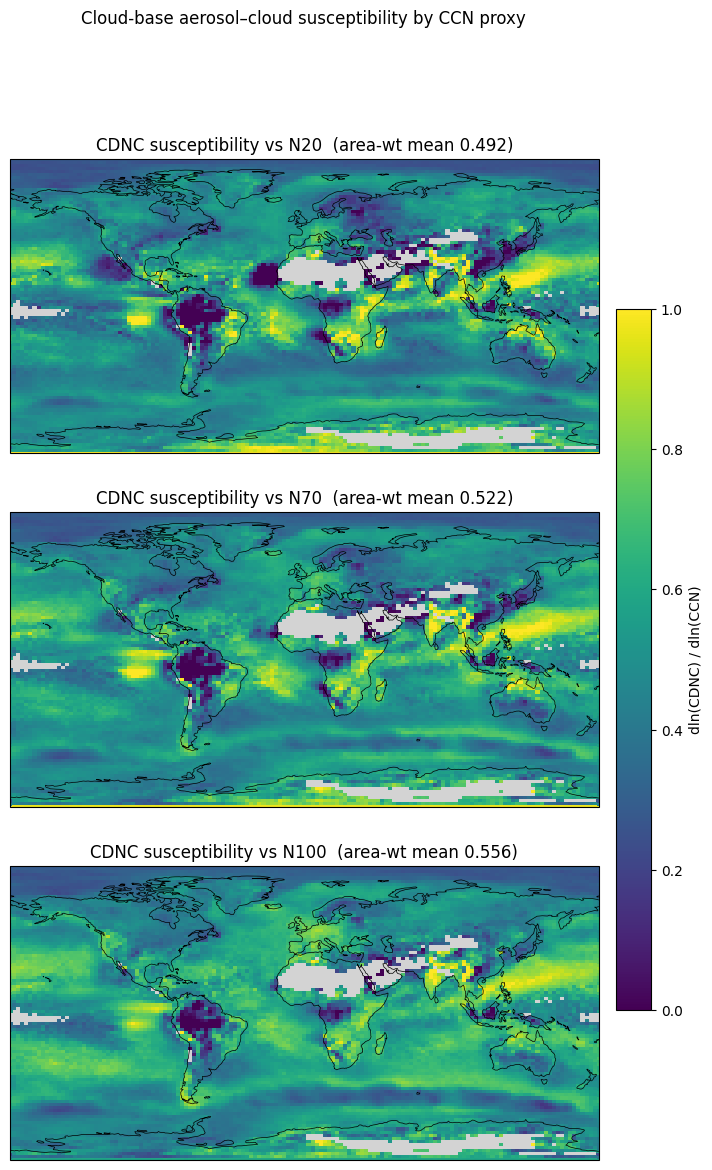

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy

# Colormap with transparent no-data; grey shows through from the background
cmap = copy.copy(plt.cm.viridis)
cmap.set_bad(alpha=0)

panels = [('N20', suscept['N20']),
          ('N70', suscept['N70']),
          ('N100', suscept['N100'])]

fig, axes = plt.subplots(3, 1, figsize=(11, 13),
                         subplot_kw={'projection': ccrs.PlateCarree()})

im = None
for ax, (name, s) in zip(axes, panels):
    # Grey base so NaN (arid no-data) cells read as grey, not blank
    ax.set_facecolor('lightgrey')
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)

    im = ax.pcolormesh(
        s['lon'], s['lat'], s.values,
        cmap=cmap, vmin=0, vmax=1,
        transform=ccrs.PlateCarree(), shading='auto', zorder=1
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ax.set_global()

    w = np.cos(np.deg2rad(s['lat']))
    awm = float(s.where(np.isfinite(s)).weighted(w).mean())
    ax.set_title(f'CDNC susceptibility vs {name}  (area-wt mean {awm:.3f})')

# Single shared colorbar
cb = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.7, pad=0.02)
cb.set_label('dln(CDNC) / dln(CCN)')

fig.suptitle('Cloud-base aerosol–cloud susceptibility by CCN proxy', y=0.995)
plt.show()

In [46]:
import numpy as np
import xarray as xr
import pandas as pd

# Per-cell summaries (time-median) of the cloud-base fields
cdnc_med = CDNC_CB.median('time', skipna=True)      # (lat, lon)
smax_med = smax_CB.median('time', skipna=True)
updr_med = Updraft_CB.median('time', skipna=True)

# Susceptibility (pick a proxy — N70 as the middle/standard one)
susc = suscept['N70']                                # (lat, lon)

# Stack to 1D and keep cells valid in all four
df = pd.DataFrame({
    'Susceptibility': susc.values.ravel(),
    'CDNC':    cdnc_med.values.ravel(),
    'Smax':    smax_med.values.ravel(),
    'Updraft': updr_med.values.ravel(),
})
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Variables span orders of magnitude → log the physical ones (not the slope)
for col in ['CDNC', 'Smax', 'Updraft']:
    df['log_' + col] = np.log(df[col].where(df[col] > 0))
df = df.dropna()

print("Spearman (robust to nonlinearity):")
print(df[['Susceptibility','CDNC','Smax','Updraft']].corr(method='spearman'))
print("\nPearson (susceptibility vs logged variables):")
print(df[['Susceptibility','log_CDNC','log_Smax','log_Updraft']].corr().loc['Susceptibility'])

Spearman (robust to nonlinearity):
                Susceptibility      CDNC      Smax   Updraft
Susceptibility        1.000000  0.049050 -0.185957  0.164988
CDNC                  0.049050  1.000000 -0.774673  0.221287
Smax                 -0.185957 -0.774673  1.000000  0.043102
Updraft               0.164988  0.221287  0.043102  1.000000

Pearson (susceptibility vs logged variables):
Susceptibility    1.000000
log_CDNC         -0.035795
log_Smax         -0.056761
log_Updraft       0.164403
Name: Susceptibility, dtype: float64


In [48]:
import numpy as np
import pandas as pd

n = N70_CB.values.ravel()
c = CDNC_CB.values.ravel()
s = smax_CB.values.ravel()
u = Updraft_CB.values.ravel()

m = np.isfinite(n) & np.isfinite(c) & np.isfinite(s) & np.isfinite(u) \
    & (n > 0) & (c > 0) & (s > 0) & (u > 0)

df = pd.DataFrame({
    'N70':     np.log(n[m]),
    'CDNC':    np.log(c[m]),
    'Smax':    np.log(s[m]),
    'Updraft': np.log(u[m]),
})

print("Pearson (log):\n", df.corr())
print("\nSpearman:\n", df.corr(method='spearman'))
print("\nN row specifically:\n", df.corr().loc['N70'])

Pearson (log):
               N70      CDNC      Smax   Updraft
N70      1.000000  0.735506 -0.927628 -0.025294
CDNC     0.735506  1.000000 -0.628201  0.238738
Smax    -0.927628 -0.628201  1.000000  0.232109
Updraft -0.025294  0.238738  0.232109  1.000000

Spearman:
               N70      CDNC      Smax   Updraft
N70      1.000000  0.717504 -0.913753 -0.033030
CDNC     0.717504  1.000000 -0.565034  0.268471
Smax    -0.913753 -0.565034  1.000000  0.248282
Updraft -0.033030  0.268471  0.248282  1.000000

N row specifically:
 N70        1.000000
CDNC       0.735506
Smax      -0.927628
Updraft   -0.025294
Name: N70, dtype: float64


In [51]:
import xarray as xr

def corr_map(a, b, min_n=50):
    n = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    cnt = n.sum(dim='time')
    la, lb = np.log(a.where(n)), np.log(b.where(n))
    la = la - la.mean('time'); lb = lb - lb.mean('time')
    r = (la * lb).mean('time') / (la.std('time') * lb.std('time'))
    return r.where(cnt >= min_n)

r_n70_cdnc = corr_map(N70_CB, CDNC_CB)
r_n70_smax = corr_map(N70_CB, smax_CB)
r_n70_updr = corr_map(N70_CB, Updraft_CB)

In [53]:
ccn_logstd = np.log(N70_CB.where(N70_CB > 0)).std('time')   # (lat,lon)
import pandas as pd, numpy as np
d = pd.DataFrame({'susc': suscept['N70'].values.ravel(),
                  'logCCN_std': ccn_logstd.values.ravel()}).dropna()
print('Spearman susc vs CCN variability:',
      d.corr(method='spearman').iloc[0,1])

Spearman susc vs CCN variability: -0.38592044120652524


In [55]:
import numpy as np, matplotlib.pyplot as plt
import dask.array as da
import numpy as np, dask
import matplotlib.pyplot as plt

def as_dask(x, chunk="auto"):
    arr = x.data
    return arr if hasattr(arr, "numblocks") else da.from_array(arr, chunks=chunk)

s_da = as_dask(smax_CB).ravel()
c_da = as_dask(CDNC_CB).ravel()
w_da = as_dask(Updraft_CB).ravel()

m  = da.isfinite(s_da) & da.isfinite(c_da) & da.isfinite(w_da) & (s_da > 0) & (c_da > 0)
ls = da.log(s_da[m]); c = c_da[m]; w = w_da[m]

xr_, yr_, bins = [np.log(1e-6), np.log(1e-1)], [0.0, 1500.0], [200, 200]
Hw, xe, ye = da.histogram2d(ls, c, bins=bins, range=[xr_, yr_], weights=w)
Hn, _, _   = da.histogram2d(ls, c, bins=bins, range=[xr_, yr_])
Hw, Hn = dask.compute(Hw, Hn)
mean_w = np.where(Hn > 0, Hw/np.maximum(Hn,1), np.nan)

ls = np.log10(smax_CB)
# s, c, w, ls already defined and masked from your diagnostic cell
lc = np.log10(CDNC_CB)   # log10 CDNC, since it spans 5e5–2e9

bins = [200, 200]
Hw, xe, ye = np.histogram2d(ls, lc, bins=bins, weights=w)   # no range -> auto-fit
Hn, _, _   = np.histogram2d(ls, lc, bins=bins)
mean_w = np.where(Hn > 0, Hw/np.maximum(Hn, 1), np.nan)

fig, ax = plt.subplots(figsize=(7,5))
pc = ax.pcolormesh(xe, ye, mean_w.T, cmap="viridis", shading="auto")
fig.colorbar(pc, ax=ax, label="mean updraft w (m/s)")
ax.set_xlabel("ln(S_max)")
ax.set_ylabel("log10(CDNC)  [m$^{-3}$]")
ax.set_title("ln(S_max) vs CDNC, colored by mean updraft")
plt.tight_layout(); plt.show()

AttributeError: 'DataArray' object has no attribute 'numblocks'

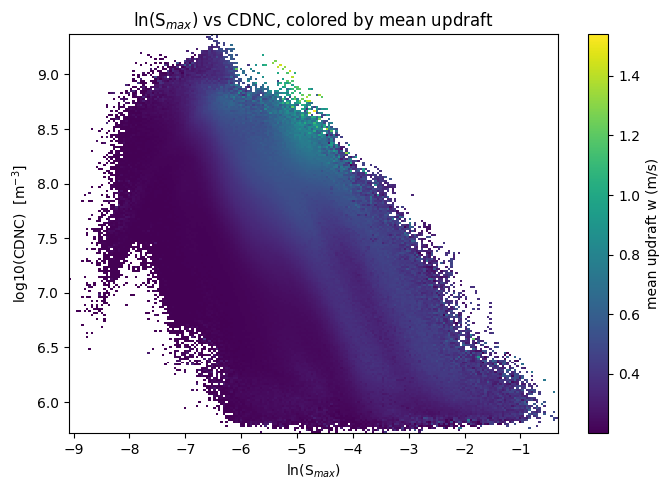

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Materialize masked 1D NumPy vectors (small after masking)
s = np.asarray(smax_CB.values).ravel()
c = np.asarray(CDNC_CB.values).ravel()      # note: lowercase _cb
w = np.asarray(Updraft_CB.values).ravel()

m = np.isfinite(s) & np.isfinite(c) & np.isfinite(w) & (s > 0) & (c > 0)
ls = np.log(s[m])          # ln(Smax)
lc = np.log10(c[m])        # log10(CDNC)
wv = w[m]                  # weights = updraft

bins = [200, 200]
Hw, xe, ye = np.histogram2d(ls, lc, bins=bins, weights=wv)
Hn, _, _   = np.histogram2d(ls, lc, bins=bins)
mean_w = np.where(Hn > 0, Hw / np.maximum(Hn, 1), np.nan)

fig, ax = plt.subplots(figsize=(7, 5))
pc = ax.pcolormesh(xe, ye, mean_w.T, cmap="viridis", shading="auto", )
fig.colorbar(pc, ax=ax, label="mean updraft w (m/s)")
ax.set_xlabel("ln(S$_{max}$)")
ax.set_ylabel("log10(CDNC)  [m$^{-3}$]")
ax.set_title("ln(S$_{max}$) vs CDNC, colored by mean updraft")
plt.tight_layout(); plt.show()

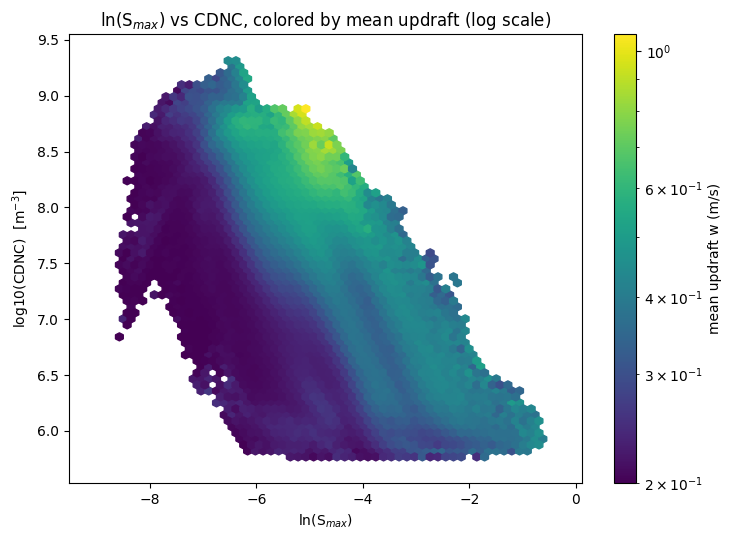

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Masked 1D vectors
s = np.asarray(smax_CB.values).ravel()
c = np.asarray(CDNC_CB.values).ravel()
w = np.asarray(Updraft_CB.values).ravel()

m = np.isfinite(s) & np.isfinite(c) & np.isfinite(w) & (s > 0) & (c > 0) & (w > 0)
ls = np.log(s[m])          # ln(Smax)
lc = np.log10(c[m])        # log10(CDNC)
wv = w[m]                  # updraft, used as the colour value

fig, ax = plt.subplots(figsize=(7.5, 5.5))
hb = ax.hexbin(
    ls, lc, C=wv,                    # C = value to reduce per hexagon
    reduce_C_function=np.mean,       # colour = mean updraft in each hexagon
    gridsize=60,
    cmap="viridis",
    norm=LogNorm(),                  # log colour scale on updraft
    mincnt=5,                        # ignore hexagons with <5 points
)
cb = fig.colorbar(hb, ax=ax, label="mean updraft w (m/s)")
ax.set_xlabel("ln(S$_{max}$)")
ax.set_ylabel("log10(CDNC)  [m$^{-3}$]")
ax.set_title("ln(S$_{max}$) vs CDNC, colored by mean updraft (log scale)")
plt.tight_layout(); plt.show()

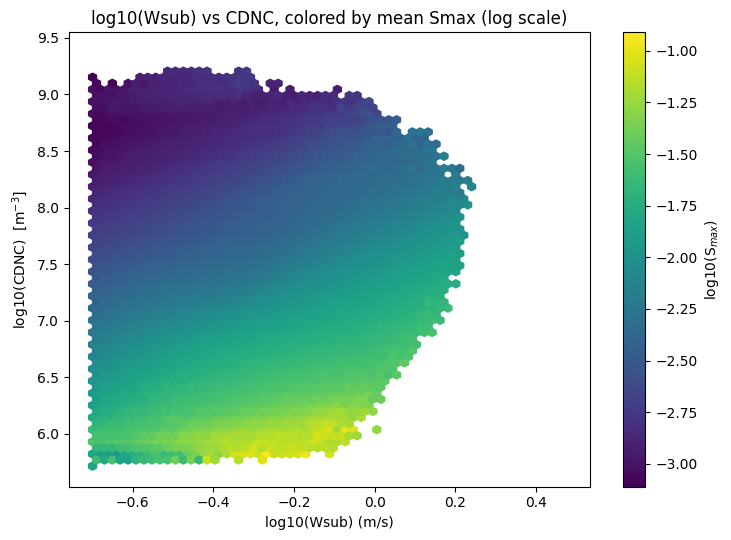

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Masked 1D vectors
s = np.asarray(smax_CB.values).ravel()
c = np.asarray(CDNC_CB.values).ravel()
w = np.asarray(Updraft_CB.values).ravel()

m = np.isfinite(s) & np.isfinite(c) & np.isfinite(w) & (s > 0) & (c > 0) & (w > 0)
ls = np.log10(s[m])          # ln(Smax)
lc = np.log10(c[m])        # log10(CDNC)
lw = np.log10(w[m])                  # updraft, used as the colour value

fig, ax = plt.subplots(figsize=(7.5, 5.5))
hb = ax.hexbin(
    lw, lc, C=ls,                    # C = value to reduce per hexagon
    reduce_C_function=np.mean,       # colour = mean updraft in each hexagon
    gridsize=60,
    cmap="viridis",
    mincnt=5,                        # ignore hexagons with <5 points
)
cb = fig.colorbar(hb, ax=ax, label="log10(S$_{max}$)")
ax.set_xlabel("log10(Wsub) (m/s)")
ax.set_ylabel("log10(CDNC)  [m$^{-3}$]")
ax.set_title("log10(Wsub) vs CDNC, colored by mean Smax (log scale)")
plt.tight_layout(); plt.show()

In [59]:
import numpy as np
import pandas as pd

# Masked, logged 1D vectors — all three positive-definite for logs
s = np.asarray(smax_CB.values).ravel()
c = np.asarray(CDNC_CB.values).ravel()
u = np.asarray(Updraft_CB.values).ravel()

m = np.isfinite(s) & np.isfinite(c) & np.isfinite(u) & (s > 0) & (c > 0) & (u > 0)
ls, lc, lu = np.log(s[m]), np.log(c[m]), np.log(u[m])

# index convention: 0=CDNC, 1=Smax, 2=Updraft
R = np.corrcoef(np.vstack([lc, ls, lu]))

def partial(R, i, j, k):
    denom = np.sqrt((1 - R[i,k]**2) * (1 - R[j,k]**2))
    return np.nan if denom == 0 else (R[i,j] - R[i,k]*R[j,k]) / denom

print("Global partial correlations (CDNC as response):")
print(f"  CDNC–Smax    | Updraft : {partial(R, 0, 1, 2):+.3f}")
print(f"  CDNC–Updraft | Smax    : {partial(R, 0, 2, 1):+.3f}")
print(f"\n  (raw CDNC–Smax    : {R[0,1]:+.3f})")
print(f"  (raw CDNC–Updraft : {R[0,2]:+.3f})")

# Spearman robustness
from scipy.stats import rankdata
Rr = np.corrcoef(np.vstack([rankdata(lc), rankdata(ls), rankdata(lu)]))
print("\nSpearman partials:")
print(f"  CDNC–Smax    | Updraft : {partial(Rr, 0, 1, 2):+.3f}")
print(f"  CDNC–Updraft | Smax    : {partial(Rr, 0, 2, 1):+.3f}")

Global partial correlations (CDNC as response):
  CDNC–Smax    | Updraft : -0.724
  CDNC–Updraft | Smax    : +0.508

  (raw CDNC–Smax    : -0.628)
  (raw CDNC–Updraft : +0.239)

Spearman partials:
  CDNC–Smax    | Updraft : -0.677
  CDNC–Updraft | Smax    : +0.511


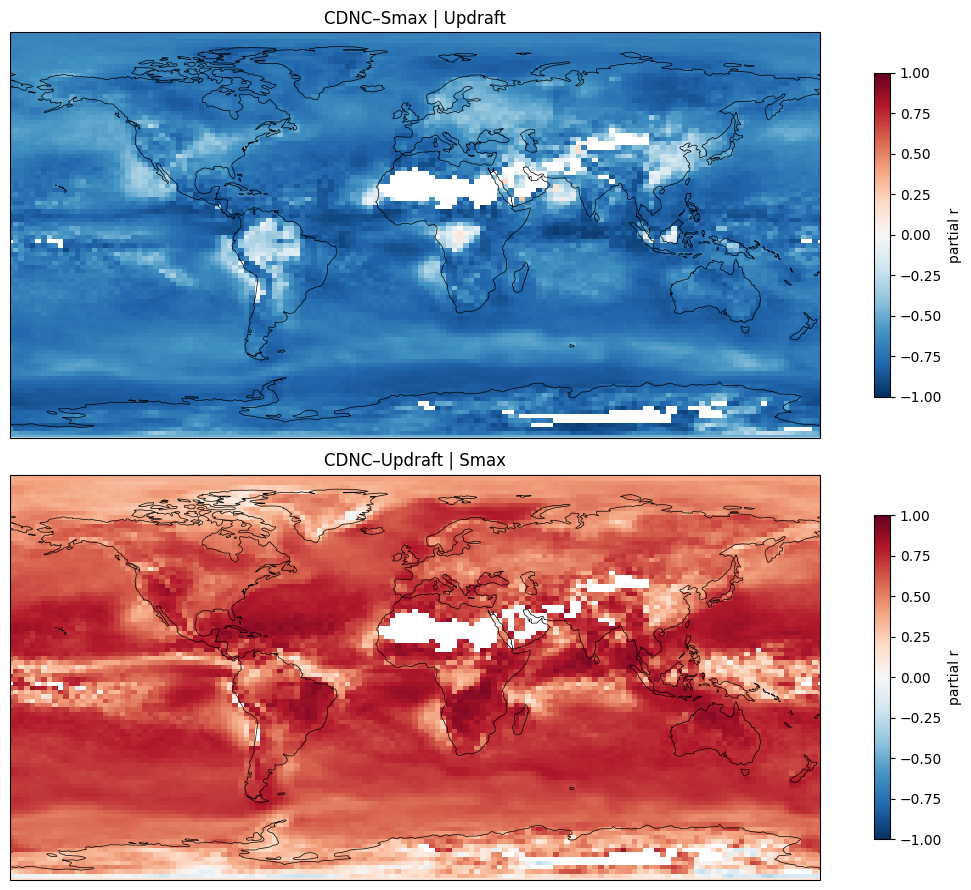

CDNC–Smax|Updraft  area-wt mean: -0.6940895961275286
CDNC–Updraft|Smax  area-wt mean: 0.6464861798189505


In [60]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

S = smax_CB.values; C = CDNC_CB.values; U = Updraft_CB.values
ntime, nlat, nlon = C.shape
MIN_N = 50

pr_cdnc_smax = np.full((nlat, nlon), np.nan, dtype=np.float32)
pr_cdnc_updr = np.full((nlat, nlon), np.nan, dtype=np.float32)

for a in range(nlat):
    for b in range(nlon):
        s_, c_, u_ = S[:, a, b], C[:, a, b], U[:, a, b]
        mm = (np.isfinite(s_) & np.isfinite(c_) & np.isfinite(u_)
              & (s_ > 0) & (c_ > 0) & (u_ > 0))
        if mm.sum() < MIN_N:
            continue
        lc_, ls_, lu_ = np.log(c_[mm]), np.log(s_[mm]), np.log(u_[mm])
        if lc_.std() == 0 or ls_.std() == 0 or lu_.std() == 0:
            continue
        Rc = np.corrcoef(np.vstack([lc_, ls_, lu_]))   # 0=CDNC,1=Smax,2=Updraft
        pr_cdnc_smax[a, b] = partial(Rc, 0, 1, 2)
        pr_cdnc_updr[a, b] = partial(Rc, 0, 2, 1)

coords = {'lat': CDNC_CB['lat'], 'lon': CDNC_CB['lon']}
m_smax = xr.DataArray(pr_cdnc_smax, dims=('lat','lon'), coords=coords,
                      name='partial_CDNC_Smax_given_Updraft')
m_updr = xr.DataArray(pr_cdnc_updr, dims=('lat','lon'), coords=coords,
                      name='partial_CDNC_Updraft_given_Smax')

# Plot both
fig, axes = plt.subplots(2, 1, figsize=(11, 9),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, dm, title in [(axes[0], m_smax, 'CDNC–Smax | Updraft'),
                      (axes[1], m_updr, 'CDNC–Updraft | Smax')]:
    im = ax.pcolormesh(dm['lon'], dm['lat'], dm.values, cmap='RdBu_r',
                       vmin=-1, vmax=1, transform=ccrs.PlateCarree(), shading='auto')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_global(); ax.set_title(title)
    plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, label='partial r')
plt.tight_layout(); plt.show()

# Validation
w = np.cos(np.deg2rad(m_smax['lat']))
print('CDNC–Smax|Updraft  area-wt mean:', float(m_smax.weighted(w).mean()))
print('CDNC–Updraft|Smax  area-wt mean:', float(m_updr.weighted(w).mean()))

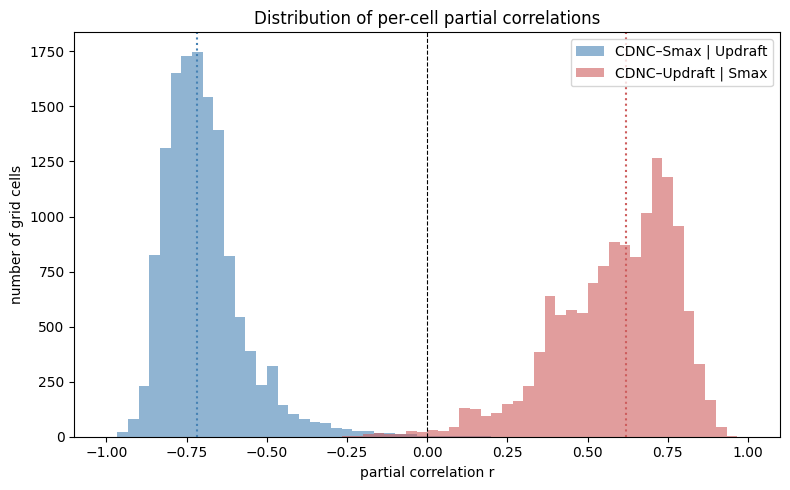

CDNC–Smax|Updraft : median -0.717, mean -0.696, n=13509
CDNC–Updraft|Smax : median +0.619, mean +0.586, n=13509
  cells where Smax-partial < 0: 99.9%
  cells where Updraft-partial > 0: 99.2%


In [61]:
import numpy as np
import matplotlib.pyplot as plt

a = m_smax.values.ravel()      # CDNC–Smax | Updraft
b = m_updr.values.ravel()      # CDNC–Updraft | Smax
a = a[np.isfinite(a)]
b = b[np.isfinite(b)]

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-1, 1, 61)
ax.hist(a, bins=bins, alpha=0.6, label='CDNC–Smax | Updraft', color='steelblue')
ax.hist(b, bins=bins, alpha=0.6, label='CDNC–Updraft | Smax', color='indianred')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axvline(np.median(a), color='steelblue', lw=1.5, ls=':')
ax.axvline(np.median(b), color='indianred', lw=1.5, ls=':')
ax.set_xlabel('partial correlation r')
ax.set_ylabel('number of grid cells')
ax.set_title('Distribution of per-cell partial correlations')
ax.legend()
plt.tight_layout(); plt.show()

print(f"CDNC–Smax|Updraft : median {np.median(a):+.3f}, "
      f"mean {a.mean():+.3f}, n={a.size}")
print(f"CDNC–Updraft|Smax : median {np.median(b):+.3f}, "
      f"mean {b.mean():+.3f}, n={b.size}")
print(f"  cells where Smax-partial < 0: {100*(a<0).mean():.1f}%")
print(f"  cells where Updraft-partial > 0: {100*(b>0).mean():.1f}%")

In [68]:
r_smax_N70    = corr_map(smax_CB, N70_CB)
r_smax_N100    = corr_map(smax_CB, N100_CB)
r_smax_N20    = corr_map(smax_CB, N20_CB)


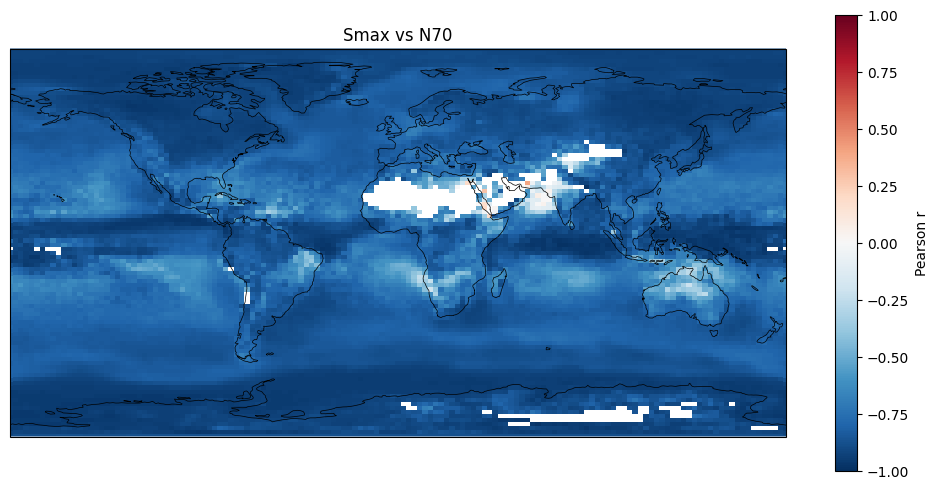

In [69]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

r, title = r_smax_N70, 'Smax vs N70'

fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(r['lon'], r['lat'], r.values,
                   cmap='RdBu_r', vmin=-1, vmax=1,
                   transform=ccrs.PlateCarree(), shading='auto')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()
ax.set_title(title)
plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, label='Pearson r')

plt.tight_layout()
plt.show()

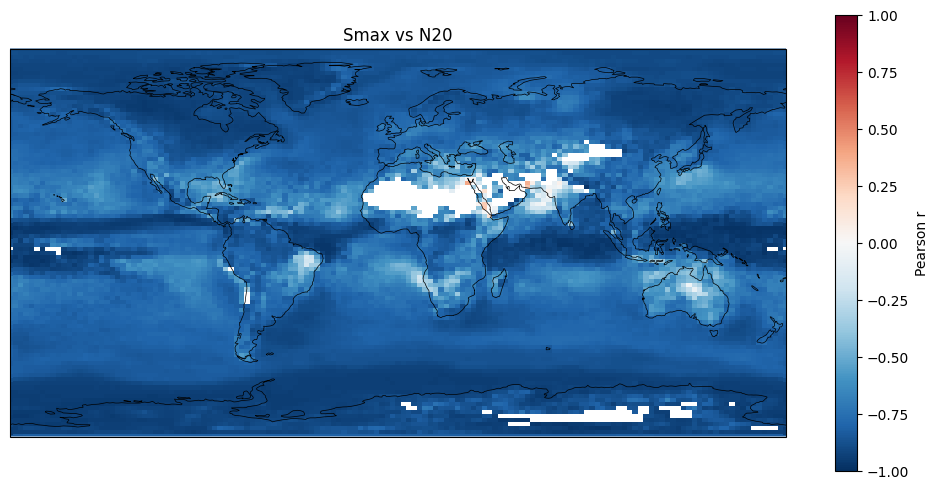

In [70]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

r, title = r_smax_N20, 'Smax vs N20'

fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(r['lon'], r['lat'], r.values,
                   cmap='RdBu_r', vmin=-1, vmax=1,
                   transform=ccrs.PlateCarree(), shading='auto')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()
ax.set_title(title)
plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, label='Pearson r')

plt.tight_layout()
plt.show()

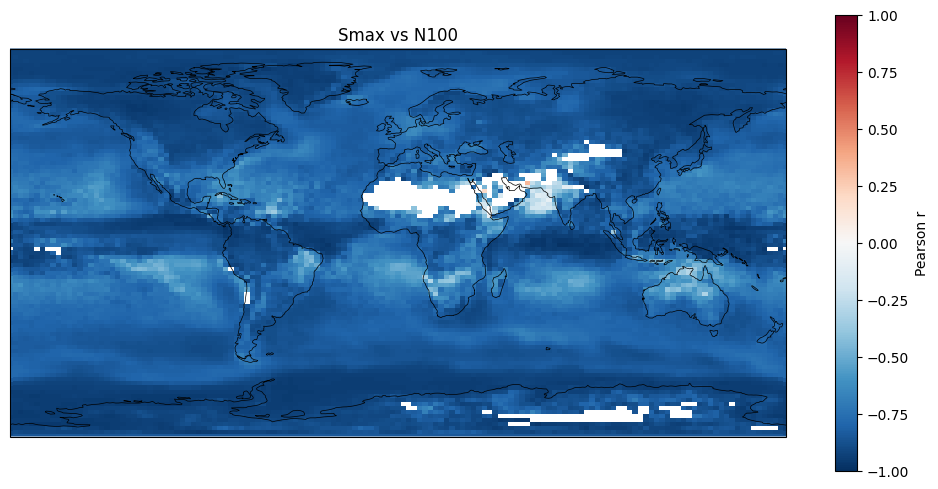

In [71]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

r, title = r_smax_N100, 'Smax vs N100'

fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(r['lon'], r['lat'], r.values,
                   cmap='RdBu_r', vmin=-1, vmax=1,
                   transform=ccrs.PlateCarree(), shading='auto')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()
ax.set_title(title)
plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, label='Pearson r')

plt.tight_layout()
plt.show()

In [76]:
testN70 = N70_CB.isel(lat = 33, lon = 33)
testCDNC = CDNC.isel(lat = 33, lon = 33)
plt.scatter(testN70,CDNC)

cell: lat -19.9, lon 270.0
valid timesteps: 2817
binned-median slope (susceptibility): 0.462
map value for cross-check:            0.472


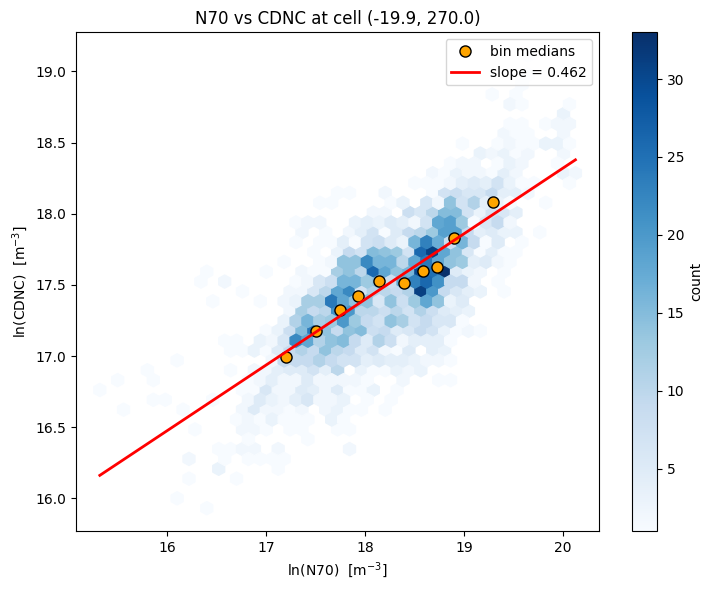

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# --- choose a location (example: SE Pacific stratocumulus deck) ---
target_lat, target_lon = -20.0, 270.0      # lon in 0–360 if your grid is
ia = int(np.abs(CDNC_CB['lat'].values - target_lat).argmin())
ib = int(np.abs(CDNC_CB['lon'].values - target_lon).argmin())
print(f"cell: lat {float(CDNC_CB['lat'][ia]):.1f}, lon {float(CDNC_CB['lon'][ib]):.1f}")

# --- pull that cell's time series ---
x_raw = N70_CB.values[:, ia, ib]
y_raw = CDNC_CB.values[:, ia, ib]

m = np.isfinite(x_raw) & np.isfinite(y_raw) & (x_raw > 0) & (y_raw > 0)
x = np.log(x_raw[m])     # ln(N70)
y = np.log(y_raw[m])     # ln(CDNC)
print(f"valid timesteps: {x.size}")

# --- recompute the binned-median slope for THIS cell (same routine as the map) ---
N_BINS, MIN_PER_BIN, MIN_BINS = 10, 5, 4
order = np.argsort(x); xs, ys = x[order], y[order]
mx, my = [], []
for chunk in np.array_split(np.arange(xs.size), N_BINS):
    if chunk.size >= MIN_PER_BIN:
        mx.append(np.median(xs[chunk])); my.append(np.median(ys[chunk]))
mx, my = np.array(mx), np.array(my)
slope, intercept = np.polyfit(mx, my, 1)
print(f"binned-median slope (susceptibility): {slope:.3f}")
print(f"map value for cross-check:            {float(suscept['N70'][ia, ib]):.3f}")

# --- joint histogram with overlays ---
fig, ax = plt.subplots(figsize=(7.5, 6))
hb = ax.hexbin(x, y, gridsize=40, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=ax, label='count')

# binned-median points
ax.plot(mx, my, 'o', color='orange', ms=8, mec='k', label='bin medians')
# fitted line across the data range
xline = np.linspace(x.min(), x.max(), 50)
ax.plot(xline, slope*xline + intercept, 'r-', lw=2,
        label=f'slope = {slope:.3f}')

ax.set_xlabel('ln(N70)  [m$^{-3}$]')
ax.set_ylabel('ln(CDNC)  [m$^{-3}$]')
ax.set_title(f'N70 vs CDNC at cell ({float(CDNC_CB["lat"][ia]):.1f}, '
             f'{float(CDNC_CB["lon"][ib]):.1f})')
ax.legend()
plt.tight_layout(); plt.show()

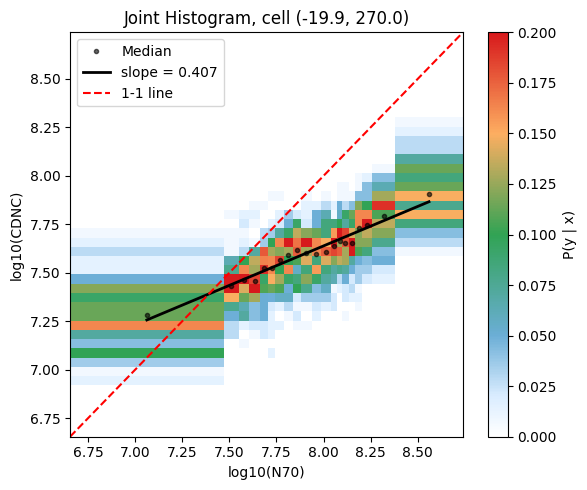

valid timesteps: 2817
slope (log10-log10): 0.407
map value:           0.472


In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- choose a cell ---
target_lat, target_lon = -20.0, 270.0
ia = int(np.abs(CDNC_CB['lat'].values - target_lat).argmin())
ib = int(np.abs(CDNC_CB['lon'].values - target_lon).argmin())

# --- this cell's time series, log10 to match your format ---
x = np.log10(N70_CB.values[:, ia, ib].flatten())
y = np.log10(CDNC_CB.values[:, ia, ib].flatten())
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

Graph_min = np.min([x.min(), y.min()])
Graph_max = np.max([x.max(), y.max()])

# --- equal-frequency bins in x, linear bins in y ---
n_bins = 20
xbins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
ybins = np.linspace(y.min(), y.max(), 30)

H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])
H_norm = H / H.sum(axis=1, keepdims=True)      # P(y | x): normalize per x-bin
H_norm = np.nan_to_num(H_norm)

# --- median per x-bin ---
x_centers = 0.5 * (xbins[:-1] + xbins[1:])
y_median = np.full(n_bins, np.nan)
for i in range(n_bins):
    mb = (x >= xbins[i]) & (x < xbins[i+1])
    if np.any(mb):
        y_median[i] = np.median(y[mb])

valid = np.isfinite(y_median)
x_fit, y_fit = x_centers[valid], y_median[valid]

# --- binned-median slope (susceptibility) for cross-check ---
slope, intercept = np.polyfit(x_fit, y_fit, 1)

# --- colormap (your paper style) ---
cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [(0.0, "#ffffff"), (0.1, "#d9ecff"), (0.25, "#6baed6"),
     (0.5, "#31a354"), (0.75, "#fdae61"), (1.0, "#d7191c")]
)

# --- plot ---
plt.figure(figsize=(6, 5))
plt.pcolormesh(xedges, yedges, H_norm.T, cmap=cmap, shading='auto', vmin=0, vmax=0.2)
plt.plot(x_fit, y_fit, 'k.', alpha=0.6, label='Median')
xline = np.linspace(x_fit.min(), x_fit.max(), 100)
plt.plot(xline, slope * xline + intercept, 'k-', lw=2, label=f'slope = {slope:.3f}')
plt.plot([Graph_min, Graph_max], [Graph_min, Graph_max], ls='--', c='red', label='1-1 line')
plt.xlim([Graph_min, Graph_max]); plt.ylim([Graph_min, Graph_max])
plt.colorbar(label='P(y | x)')
plt.xlabel('log10(N70)')
plt.ylabel('log10(CDNC)')
plt.title(f'Joint Histogram, cell ({float(CDNC_CB["lat"][ia]):.1f}, '
          f'{float(CDNC_CB["lon"][ib]):.1f})')
plt.legend()
plt.tight_layout(); plt.show()

print(f"valid timesteps: {x.size}")
print(f"slope (log10-log10): {slope:.3f}")
print(f"map value:           {float(suscept['N70'][ia, ib]):.3f}")

=== slope cross-check for this cell ===
  (1) map routine, natural log : 0.4617
  (2) map routine, log10       : 0.4617
      stored map value         : 0.4718
  (3) 20-bin quantile (plot)   : 0.4073

  (1) vs map value  match? False
  (1) vs (2) match (base cancels)? True


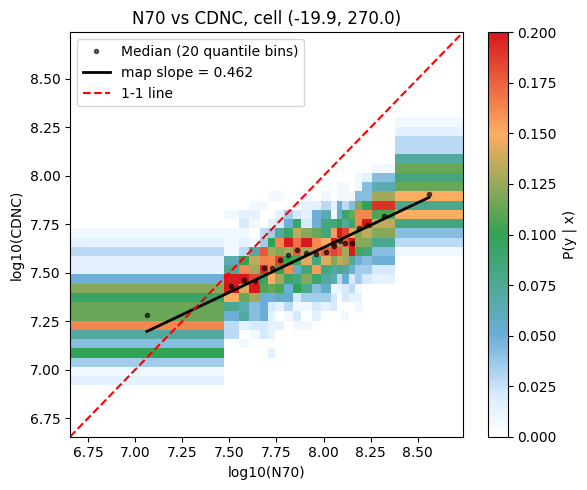

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------------------------------------------
# The EXACT routine used to build the susceptibility map.
# Reuse it verbatim so the validation is apples-to-apples.
# ---------------------------------------------------------------
N_BINS, MIN_PER_BIN, MIN_BINS = 10, 5, 4

def binned_slope(x, y):
    if x.size < N_BINS * MIN_PER_BIN:
        return np.nan
    order = np.argsort(x); x, y = x[order], y[order]
    mx, my = [], []
    for chunk in np.array_split(np.arange(x.size), N_BINS):
        if chunk.size >= MIN_PER_BIN:
            mx.append(np.median(x[chunk])); my.append(np.median(y[chunk]))
    if len(mx) < MIN_BINS:
        return np.nan
    return np.polyfit(mx, my, 1)[0]

# --- choose a cell ---
target_lat, target_lon = -20.0, 270.0
ia = int(np.abs(CDNC_CB['lat'].values - target_lat).argmin())
ib = int(np.abs(CDNC_CB['lon'].values - target_lon).argmin())

# --- raw time series for this cell ---
x_raw = N70_CB.values[:, ia, ib].flatten()
y_raw = CDNC_CB.values[:, ia, ib].flatten()
mask = np.isfinite(x_raw) & np.isfinite(y_raw) & (x_raw > 0) & (y_raw > 0)

# ---------------------------------------------------------------
# THREE slope estimates, all on the same cell:
#  (1) map routine in natural log  -> must equal the stored map value
#  (2) map routine in log10        -> must equal (1) (base cancels)
#  (3) 20-bin quantile (the plot)  -> should be close, not necessarily identical
# ---------------------------------------------------------------
xln, yln = np.log(x_raw[mask]),   np.log(y_raw[mask])     # natural log
x10, y10 = np.log10(x_raw[mask]), np.log10(y_raw[mask])   # log10

slope_map_ln  = binned_slope(xln, yln)
slope_map_l10 = binned_slope(x10, y10)
map_value     = float(suscept['N70'][ia, ib])

# 20-bin quantile median regression (for the smooth-looking figure)
x, y = x10, y10
n_bins = 20
xbins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
x_centers = 0.5 * (xbins[:-1] + xbins[1:])
y_median = np.full(n_bins, np.nan)
for i in range(n_bins):
    mb = (x >= xbins[i]) & (x < xbins[i+1])
    if np.any(mb):
        y_median[i] = np.median(y[mb])
valid = np.isfinite(y_median)
x_fit, y_fit = x_centers[valid], y_median[valid]
slope_q20, intercept_q20 = np.polyfit(x_fit, y_fit, 1)

print("=== slope cross-check for this cell ===")
print(f"  (1) map routine, natural log : {slope_map_ln:.4f}")
print(f"  (2) map routine, log10       : {slope_map_l10:.4f}")
print(f"      stored map value         : {map_value:.4f}")
print(f"  (3) 20-bin quantile (plot)   : {slope_q20:.4f}")
print()
print(f"  (1) vs map value  match? {np.isclose(slope_map_ln, map_value, atol=1e-4)}")
print(f"  (1) vs (2) match (base cancels)? {np.isclose(slope_map_ln, slope_map_l10, atol=1e-6)}")

# ---------------------------------------------------------------
# Plot: smooth 20-bin histogram + 20-bin medians, but draw the
# MAP routine's slope (log10 version) so the line shown is the
# one your map actually used.
# ---------------------------------------------------------------
ybins = np.linspace(y.min(), y.max(), 30)
H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])
H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))
Graph_min = np.min([x.min(), y.min()]); Graph_max = np.max([x.max(), y.max()])

cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [(0.0, "#ffffff"), (0.1, "#d9ecff"), (0.25, "#6baed6"),
     (0.5, "#31a354"), (0.75, "#fdae61"), (1.0, "#d7191c")]
)

plt.figure(figsize=(6, 5))
plt.pcolormesh(xedges, yedges, H_norm.T, cmap=cmap, shading='auto', vmin=0, vmax=0.2)
plt.plot(x_fit, y_fit, 'k.', alpha=0.6, label='Median (20 quantile bins)')

# the map's actual slope line (log10), anchored at the data's log10 means
xm, ym = x.mean(), y.mean()
xline = np.linspace(x_fit.min(), x_fit.max(), 100)
plt.plot(xline, slope_map_l10 * (xline - xm) + ym, 'k-', lw=2,
         label=f'map slope = {slope_map_l10:.3f}')

plt.plot([Graph_min, Graph_max], [Graph_min, Graph_max], ls='--', c='red', label='1-1 line')
plt.xlim([Graph_min, Graph_max]); plt.ylim([Graph_min, Graph_max])
plt.colorbar(label='P(y | x)')
plt.xlabel('log10(N70)'); plt.ylabel('log10(CDNC)')
plt.title(f'N70 vs CDNC, cell ({float(CDNC_CB["lat"][ia]):.1f}, '
          f'{float(CDNC_CB["lon"][ib]):.1f})')
plt.legend()
plt.tight_layout(); plt.show()

In [83]:
import numpy as np

# Recompute susceptibility for THIS cell from the current arrays,
# exactly as susceptibility_map does internally:
X = np.log(N70_CB.values); Y = np.log(CDNC_CB.values)
finite = np.isfinite(X) & np.isfinite(Y)
mm = finite[:, ia, ib]
fresh = binned_slope(X[mm, ia, ib], Y[mm, ia, ib])
print(f"fresh recompute (this cell): {fresh:.4f}")
print(f"slope (1):                   {slope_map_ln:.4f}")
print(f"stored map value:            {map_value:.4f}")
print(f"fresh vs (1) match? {np.isclose(fresh, slope_map_ln, atol=1e-6)}")

fresh recompute (this cell): 0.4617
slope (1):                   0.4617
stored map value:            0.4718
fresh vs (1) match? True


In [84]:
print("zeros in N70 cell:", (N70_CB.values[:, ia, ib] == 0).sum())
print("zeros in CDNC cell:", (CDNC_CB.values[:, ia, ib] == 0).sum())

zeros in N70 cell: 0
zeros in CDNC cell: 0


In [85]:
for v in ['CDNC_cb', 'N70_cb', 'N20_cb', 'N100_cb']:
    if v in dir():
        exec(f'del {v}')

In [86]:
suscept = {}
for name, ccn_cb in [('N20', N20_CB), ('N70', N70_CB), ('N100', N100_CB)]:
    print(f'recomputing susceptibility vs {name}...')
    suscept[name] = susceptibility_map(ccn_cb, CDNC_CB)

# confirm the cell now matches
print('cell value after rebuild:', float(suscept['N70'][ia, ib]),
      'vs fresh', round(slope_map_ln, 4))

recomputing susceptibility vs N20...
recomputing susceptibility vs N70...
recomputing susceptibility vs N100...
cell value after rebuild: 0.4616847336292267 vs fresh 0.4617


In [87]:
import numpy as np
print("Cross-proxy susceptibility (rebuilt, validated arrays):")
for name in ['N20', 'N70', 'N100']:
    s = suscept[name]
    w = np.cos(np.deg2rad(s['lat']))
    awm = float(s.where(np.isfinite(s)).weighted(w).mean())
    n_valid = int(np.isfinite(s).sum())
    print(f"  {name:4s}: area-wt mean {awm:.3f}, valid {n_valid}/{s.size}")
    

Cross-proxy susceptibility (rebuilt, validated arrays):
  N20 : area-wt mean 0.498, valid 13528/13824
  N70 : area-wt mean 0.528, valid 13528/13824
  N100: area-wt mean 0.563, valid 13528/13824
